# Feature Engineering auf User-Level (Woche 2)

Nachdem wir die Daten bereinigt haben (`session_base.csv` und `not_canceled_trips.csv`), werden wir nun alle Events so aggregieren, dass jede Zeile genau einem Nutzer (`user_id`) entspricht. 

Wir werden neue Features erschaffen, die die Eigenschaften und das Verhalten des Kunden widerspiegeln.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Wir laden die gereinigten Daten aus Woche 1
sessions = pd.read_csv('../data/session_base.csv')
trips = pd.read_csv('../data/not_canceled_trips.csv')

print(f"Sessions: {len(sessions)}, Trips: {len(trips)}")

Sessions: 50547, Trips: 16827


## 1. Features aus allen Interaktionen (`session_base`)
Wir ermitteln, wie oft ein User die Seite besucht, wie oft er storniert (Cancellation Rate) und wie oft er nur "Window Shopping" betreibt (Sessions, bei denen er gar nichts bucht).

In [4]:
# Window-Shopping (Nichts gebucht)
sessions['is_window_shopping'] = ((sessions['flight_booked'] == False) & (sessions['hotel_booked'] == False)).astype(int)
sessions['has_discount'] = (sessions['flight_discount'] | sessions['hotel_discount']).astype(int)
sessions['cancellation'] = sessions['cancellation'].astype(int)

user_sessions = sessions.groupby('user_id').agg(
    total_sessions=('session_id', 'count'),
    total_cancellations=('cancellation', 'sum'),
    window_shopping_sessions=('is_window_shopping', 'sum'),
    total_discount_sessions=('has_discount', 'sum'),
    total_page_clicks=('page_clicks', 'sum'),
        avg_page_clicks=('page_clicks', 'mean'),
        birthdate=('birthdate', 'first'),
        gender=('gender', 'first'),
        married=('married', 'first'),
        has_children=('has_children', 'first')
).reset_index()

# Ratios (Raten)
user_sessions['cancellation_rate'] = user_sessions['total_cancellations'] / user_sessions['total_sessions']
user_sessions['window_shopping_rate'] = user_sessions['window_shopping_sessions'] / user_sessions['total_sessions']
user_sessions['discount_affinity'] = user_sessions['total_discount_sessions'] / user_sessions['total_sessions']

# Demografische Features konvertieren
reference_date = pd.to_datetime('2026-01-01')
user_sessions['age'] = (reference_date - pd.to_datetime(user_sessions['birthdate'], errors='coerce')).dt.days // 365
user_sessions['is_married'] = user_sessions['married'].fillna(False).astype(int)
user_sessions['has_kids'] = user_sessions['has_children'].fillna(False).astype(int)
user_sessions['age'] = user_sessions['age'].fillna(user_sessions['age'].median())
user_sessions.drop(columns=['birthdate', 'gender', 'married', 'has_children'], inplace=True)

user_sessions.head()

,user_id,total_sessions,total_cancellations,window_shopping_sessions,total_discount_sessions,total_page_clicks,avg_page_clicks,cancellation_rate,window_shopping_rate,discount_affinity,age,is_married,has_kids
0,23557,12,1,7,4,185,15.416667,0.083333,0.583333,0.333333,67,1,0
1,94883,12,0,9,3,100,8.333333,0.000000,0.750000,0.250000,53,1,0
2,101486,13,1,8,5,230,17.692308,0.076923,0.615385,0.384615,53,1,1
3,101961,12,0,5,4,218,18.166667,0.000000,0.416667,0.333333,45,1,0
4,106907,14,1,10,3,289,20.642857,0.071429,0.714286,0.214286,47,1,1


## 2. Features aus den tatsächlichen Reisen (`not_canceled_trips`)
Wir betrachten nun, ob der Kunde eher geschäftlich unterwegs ist (Fliegt alleine, wenig Gepäck, kurz) oder ein Familien-Trip macht (viele Sitze, mehrere Räume). Zudem berechnen wir den **Customer Lifetime Value (Total Spend)**.

In [5]:
# Gesamtkosten
trips['flight_cost'] = trips['base_fare_usd'].fillna(0)
trips['hotel_cost'] = (trips['hotel_per_room_usd'] * trips['rooms'] * trips['nights']).fillna(0)
trips['trip_total_cost'] = trips['flight_cost'] + trips['hotel_cost']

# Business-Trip Annahme: Fliegt alleine (1 Seat) UND wenig/kein Aufgabegepäck (<=1) UND eher kurz (Nights <= 3)
trips['is_business_trip'] = (
    (trips['flight_booked'] == True) & 
    (trips['seats'] == 1) & 
    (trips['checked_bags'].fillna(0) <= 1) &
    (trips['nights'].fillna(0) <= 3)
).astype(int)

# Family-Trip Annahme: Mehr als 2 Sitze oder mehr als 1 Zimmer gebucht
trips['is_family_trip'] = (
    (trips['seats'] > 2) | 
    (trips['rooms'] > 1)
).astype(int)

# Aggregieren!
# Vorlaufzeit der Buchung berechnen (Booking Lead Time)
trips['session_start'] = pd.to_datetime(trips['session_start'])
trips['flight_start'] = pd.to_datetime(trips['departure_time'])
trips['hotel_start'] = pd.to_datetime(trips['check_in_time'])
trips['travel_start'] = trips[['flight_start', 'hotel_start']].min(axis=1)
trips['booking_lead_time'] = (trips['travel_start'] - trips['session_start']).dt.days
trips['booking_lead_time'] = trips['booking_lead_time'].fillna(0)

user_trips = trips.groupby('user_id').agg(
    total_trips=('trip_id', 'count'),
    total_spent=('trip_total_cost', 'sum'),
    avg_spent_per_trip=('trip_total_cost', 'mean'),
    avg_nights_hotel=('nights', 'mean'),
    avg_booking_lead_time=('booking_lead_time', 'mean'),
    total_business_trips=('is_business_trip', 'sum'),
    total_family_trips=('is_family_trip', 'sum')
).reset_index()

user_trips.head()

,user_id,total_trips,total_spent,avg_spent_per_trip,avg_nights_hotel,avg_booking_lead_time,total_business_trips,total_family_trips
0,23557,4,4759.71,1189.927500,7.333333,105.500000,2,1
1,94883,3,5584.86,1861.620000,1.000000,60.333333,1,1
2,101486,4,9484.27,2371.067500,6.000000,47.750000,2,2
3,101961,7,5080.20,725.742857,3.285714,6.571429,3,0
4,106907,3,20555.57,6851.856667,7.666667,77.000000,1,1


## 3. Beide Tabellen zusammenfügen (Left Join)
Wir führen einen **Left Join** durch, da wir alle Besucher (aus `session_base.csv`) behalten wollen, auch diejenigen, die noch gar keine Reise gebucht haben (`total_trips` = 0). 

In [6]:
user_base = pd.merge(user_sessions, user_trips, on='user_id', how='left')

# Auffüllen der fehlenden Werte für Leute, die nichts gekauft haben
fill_cols = ['total_trips', 'total_spent', 'avg_spent_per_trip', 'avg_nights_hotel', 'avg_booking_lead_time', 'total_business_trips', 'total_family_trips']
user_base[fill_cols] = user_base[fill_cols].fillna(0)

# Verhältnisse (Ratios) berechnen
user_base['business_trip_ratio'] = np.where(user_base['total_trips'] > 0, user_base['total_business_trips'] / user_base['total_trips'], 0)
user_base['family_trip_ratio'] = np.where(user_base['total_trips'] > 0, user_base['total_family_trips'] / user_base['total_trips'], 0)

print(f"Finale User Base Shape: {user_base.shape}")
display(user_base.head())

Finale User Base Shape: (5998, 22)


,user_id,total_sessions,total_cancellations,window_shopping_sessions,total_discount_sessions,total_page_clicks,avg_page_clicks,cancellation_rate,window_shopping_rate,discount_affinity,...,has_kids,total_trips,total_spent,avg_spent_per_trip,avg_nights_hotel,avg_booking_lead_time,total_business_trips,total_family_trips,business_trip_ratio,family_trip_ratio
0,23557,12,1,7,4,185,15.416667,0.083333,0.583333,0.333333,...,0,4.0,4759.71,1189.927500,7.333333,105.500000,2.0,1.0,0.500000,0.250000
1,94883,12,0,9,3,100,8.333333,0.000000,0.750000,0.250000,...,0,3.0,5584.86,1861.620000,1.000000,60.333333,1.0,1.0,0.333333,0.333333
2,101486,13,1,8,5,230,17.692308,0.076923,0.615385,0.384615,...,1,4.0,9484.27,2371.067500,6.000000,47.750000,2.0,2.0,0.500000,0.500000
3,101961,12,0,5,4,218,18.166667,0.000000,0.416667,0.333333,...,0,7.0,5080.20,725.742857,3.285714,6.571429,3.0,0.0,0.428571,0.000000
4,106907,14,1,10,3,289,20.642857,0.071429,0.714286,0.214286,...,1,3.0,20555.57,6851.856667,7.666667,77.000000,1.0,1.0,0.333333,0.333333


## 4. Feature Visualisierung
Wie verhalten sich unsere generierten Features in der Praxis? Gibt es logische Zusammenhänge?

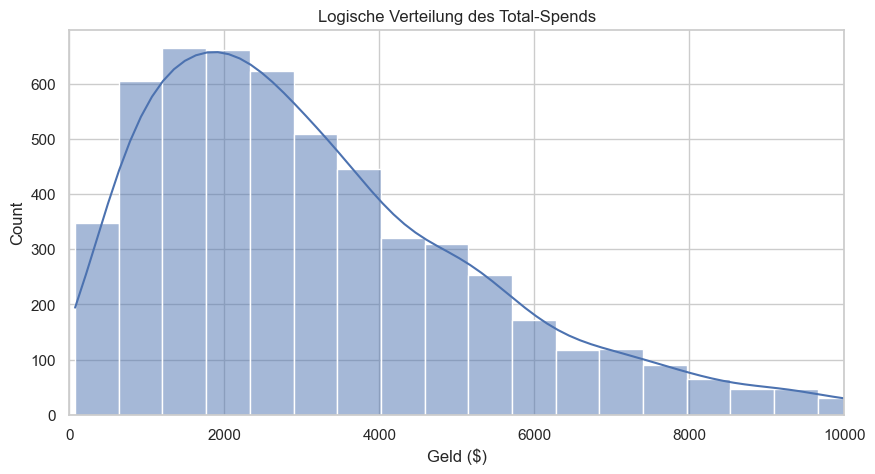

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(user_base[user_base['total_spent'] > 0]['total_spent'], bins=50, kde=True)
plt.title('Logische Verteilung des Total-Spends')
plt.xlabel('Geld ($)')
plt.xlim(0, 10000)
plt.show()

Das sieht gut aus. Wir können die CSV-Datei nun abspeichern!

In [8]:
output_path = '../data/user_base.csv'
user_base.to_csv(output_path, index=False)
print("✅ User-Dataset erfolgreich als 'user_base.csv' exportiert.")

✅ User-Dataset erfolgreich als 'user_base.csv' exportiert.
